In [1]:
import xarray as xr
import agrifoodpy as afp
from agrifoodpy.pipeline import Pipeline
from agrifoodpy.utils.scaling import linear_scale

In [2]:
shocks_pipeline = Pipeline.read("test_shocks_registration_many_years.yaml")

In [3]:
resilience_adoption = linear_scale(
    2020,
    2020,
    2030,
    2050,
    0.0,
    1.0
)

resilience_channels = xr.DataArray(
    [0.0, 1.0, 0.0, 1.0],
    coords={"channels": ["Bio", "Log", "Lab", "Mark"]},
    dims=["channels"]
)

resilience = resilience_adoption * resilience_channels

shocks_pipeline.params[1]["resilience"] = resilience

In [4]:
shocks_pipeline.run(timing=True)

Node 1: Load UK Food Data,                       executed in 0.0218 seconds.
Node 2: Cyber security,                       executed in 0.0038 seconds.
Node 3: Cyber attack,                       executed in 0.0069 seconds.
Node 4: Process shocks,                       executed in 0.0112 seconds.
Pipeline executed in 0.0439 seconds.


In [5]:
food = shocks_pipeline.datablock["shocked_food"]

<Axes: >

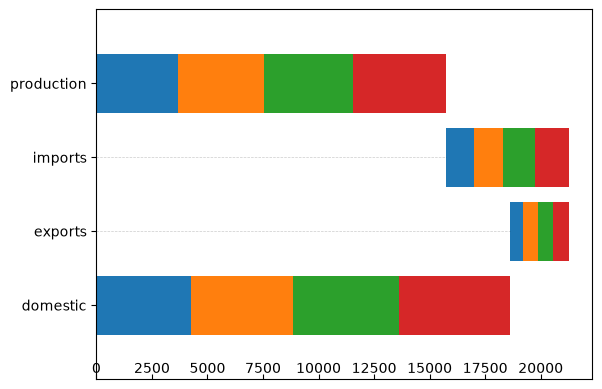

In [6]:
food.fbs.plot_bars(
    elements=["production", "imports"],
    inverted_elements=["exports", "domestic"],
)

<Axes: xlabel='Year'>

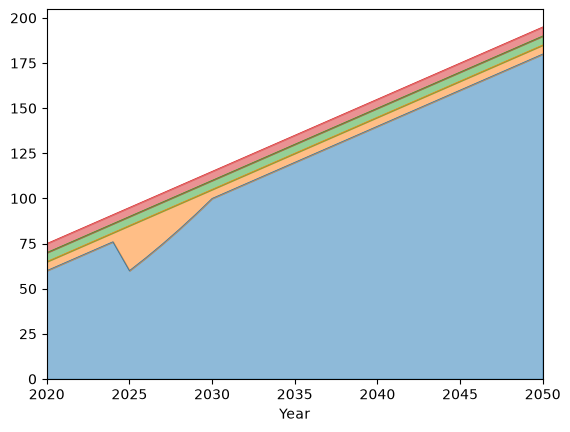

In [7]:
food["production"].fbs.plot_years(
    show="Item",
    stack=False
)